### 準確率 (Accuracy)
表示模型正確預測的案例（真陽性和真陰性）占所有案例的比例。公式如下：
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

### 精確率 (Precision)我要找到更多精準找到陽性的人 但可能抓錯人
表示被模型預測為陽性且實際上也為陽性的案例占所有被模型預測為陽性的案例的比例。公式如下：

降低假陽(FP)我提高了病毒的量 並度量要高才算陽 但是有些少量病毒的也因該是陽性所以FN上升
$$ \text{Precision} = \frac{TP}{TP + FP} $$

### 召回率 (Recall) 或稱敏感度 (Sensitivity) 我要找到更多陽性的人
表示被模型預測為陽性且實際上也為陽性的案例占所有實際陽性案例的比例。公式如下：

降低假英(FN)我降低了病毒的量 但是有些少量病毒就算陽 但是這要FP(假陽就可能上升)
$$ \text{Recall} = \frac{TP}{TP + FN} $$

## 精確率 與 召回率 此消彼漲
FP想變小FN有可能多 FN想變小FP可能多這就是 消彼長的關係原因

### F1 Score
為精確率與召回率的調和平均數，是兩者之間的平衡。公式如下：
$$ \text{F1 Score} = \frac{2 \times TP}{2 \times TP + FP + FN} $$

# 羅吉斯迴歸（Logistic Regression）

### 適合二分法

- e很大X越靠近0

- e很小X越無限大

In [1]:
import numpy as np
for x in range(-10,11):
    print(x,np.exp(-x))

-10 22026.465794806718
-9 8103.083927575384
-8 2980.9579870417283
-7 1096.6331584284585
-6 403.4287934927351
-5 148.4131591025766
-4 54.598150033144236
-3 20.085536923187668
-2 7.38905609893065
-1 2.718281828459045
0 1.0
1 0.36787944117144233
2 0.1353352832366127
3 0.049787068367863944
4 0.01831563888873418
5 0.006737946999085467
6 0.0024787521766663585
7 0.0009118819655545162
8 0.00033546262790251185
9 0.00012340980408667956
10 4.5399929762484854e-05


In [2]:
import numpy as np

# 定義羅吉斯函數
def logistic_function(x):
    return 1 / (1 + np.exp(-x))

# 計算範圍從 -10 到 10 的羅吉斯函數值
x_values = np.linspace(-10, 10, 21)  # 產生從 -10 到 10 的21個點
logistic_values = logistic_function(x_values)

# 輸出結果
list(zip(x_values, logistic_values))

[(np.float64(-10.0), np.float64(4.5397868702434395e-05)),
 (np.float64(-9.0), np.float64(0.00012339457598623172)),
 (np.float64(-8.0), np.float64(0.0003353501304664781)),
 (np.float64(-7.0), np.float64(0.0009110511944006454)),
 (np.float64(-6.0), np.float64(0.0024726231566347743)),
 (np.float64(-5.0), np.float64(0.0066928509242848554)),
 (np.float64(-4.0), np.float64(0.01798620996209156)),
 (np.float64(-3.0), np.float64(0.04742587317756678)),
 (np.float64(-2.0), np.float64(0.11920292202211755)),
 (np.float64(-1.0), np.float64(0.2689414213699951)),
 (np.float64(0.0), np.float64(0.5)),
 (np.float64(1.0), np.float64(0.7310585786300049)),
 (np.float64(2.0), np.float64(0.8807970779778823)),
 (np.float64(3.0), np.float64(0.9525741268224334)),
 (np.float64(4.0), np.float64(0.9820137900379085)),
 (np.float64(5.0), np.float64(0.9933071490757153)),
 (np.float64(6.0), np.float64(0.9975273768433653)),
 (np.float64(7.0), np.float64(0.9990889488055994)),
 (np.float64(8.0), np.float64(0.9996646498695

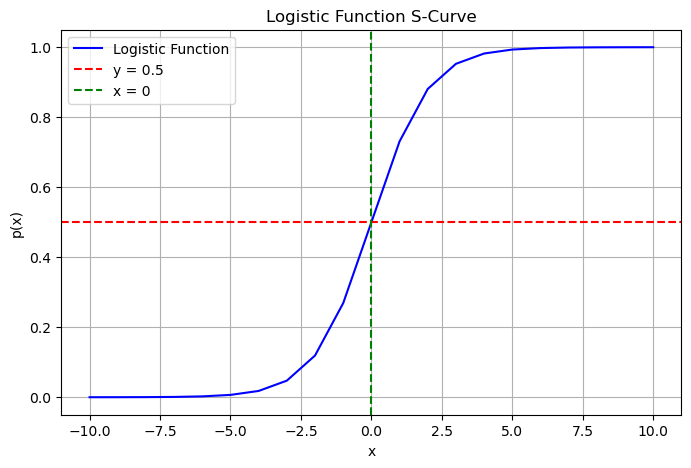

In [3]:
import matplotlib.pyplot as plt

# 使用上一步計算的數據來繪製羅吉斯函數的圖
plt.figure(figsize=(8, 5))
plt.plot(x_values, logistic_values, label='Logistic Function', color='blue')
plt.title('Logistic Function S-Curve')
plt.xlabel('x')
plt.ylabel('p(x)')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='y = 0.5')
plt.axvline(x=0, color='g', linestyle='--', label='x = 0')
plt.legend()
plt.show()

## 數據

一項實驗對5000名參與者進行了研究，以研究年齡和身體健康對聽力損失，特別是對聽到高音頻聲音的影響。這些數據顯示了研究的結果，參與者被評估並獲得身體能力分數，然後進行音頻測試（通過/不通過），以評估他們聽到高頻聲音的能力。同時記錄了參與者的年齡。是否有可能根據參與者的特徵（年齡和身體分數）建立一個模型來預測某人聽到高頻聲音的可能性？

* 特徵

    * age - 參與者的年齡（以年為單位）
    * physical_score - 身體測試中獲得的分數

* 標籤/目標

    * test_result - 如果未通過，則為0；如果通過測試，則為1

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()

In [5]:
df = pd.read_csv("hearing_test.csv")
df.head()

,age,physical_score,test_result
0,33.0,40.7,1
1,50.0,37.2,1
2,52.0,24.7,0
3,56.0,31.0,0
4,35.0,42.9,1


In [8]:
df2 = df.sort_values(by="age",ascending=False)
df2[df2["test_result"] == 1]

,age,physical_score,test_result
1075,71.0,28.4,1
3693,71.0,31.9,1
4428,69.0,30.9,1
2845,68.0,35.3,1
3895,68.0,28.6,1
...,...,...,...
2215,22.0,46.9,1
2268,22.0,41.8,1
3196,21.0,46.3,1
1187,21.0,46.5,1


<Axes: xlabel='age', ylabel='physical_score'>

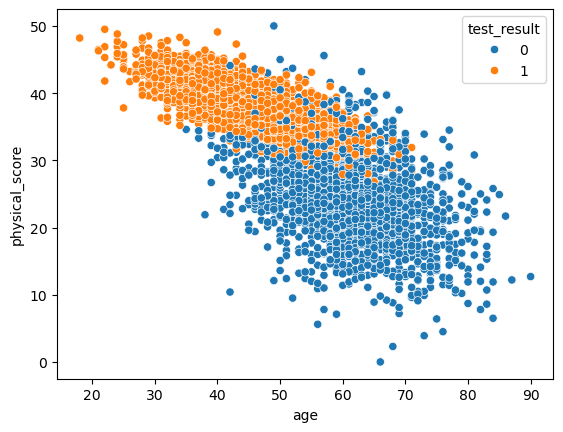

In [9]:
sns.scatterplot(x="age",y="physical_score",data=df,hue="test_result")

<Axes: >

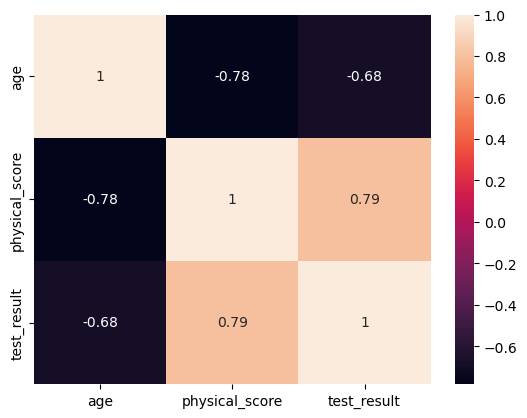

In [11]:
sns.heatmap(df.corr(),annot=True)

In [12]:
X = df.drop("test_result",axis=1)
y = df["test_result"]

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)


In [14]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [15]:
log_model = LogisticRegression()
log_model.fit(scaled_X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [16]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = log_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.93

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       193
           1       0.93      0.95      0.94       307

    accuracy                           0.93       500
   macro avg       0.93      0.92      0.93       500
weighted avg       0.93      0.93      0.93       500



# Multi-Class Logistic Regression


In [19]:
df = pd.read_csv("iris.csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [26]:
X = df.drop("species",axis=1)
y = df["species"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=101)
scaler = StandardScaler()
scaled_X_train  = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier#分類問題轉化為多個二元分類問題

In [30]:
#saga 才可使用l1 l2
log_model = LogisticRegression(solver="saga",max_iter=5000)
oneVsRest_model = OneVsRestClassifier(log_model)

In [31]:
penalty = ["l1","l2"]
"""
0 表示10^0 = 1 開始
4 表示10^4 = 10000 結束
10 分10斷
指數範圍從10^0 到 10^4平均切10個點
"""
C = np.logspace(0,4,10)
print(C)
grid_model = GridSearchCV(oneVsRest_model, param_grid={'estimator__C': C,
                                                  'estimator__penalty': penalty})
grid_model.fit(scaled_X_train,y_train)

[1.00000000e+00 2.78255940e+00 7.74263683e+00 2.15443469e+01
 5.99484250e+01 1.66810054e+02 4.64158883e+02 1.29154967e+03
 3.59381366e+03 1.00000000e+04]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",OneVsRestClas...olver='saga'))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__C': array([1.0000...00000000e+04]), 'estimator__penalty': ['l1', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [32]:
y_pred = grid_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

1.0

## GridSearchCV and Pipline

In [33]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [34]:
X = df.drop("target",axis=1)
y = df["target"]

## 建立管道

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LinearRegression

In [38]:
pipeline = Pipeline([("scaler",StandardScaler()),
                     ("regression",LinearRegression())])

In [36]:
from sklearn.model_selection import train_test_split
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


In [39]:
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [40]:
from sklearn.metrics import mean_squared_error
y_pred = pipeline.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5289841670367209

In [41]:
import pandas as pd
df = pd.read_csv("./california_housing_data.csv")
X = df.drop("target",axis=1)
y = df["target"]

In [42]:
from sklearn.model_selection import train_test_split,GridSearchCV
# 將數據分為訓練集和測試集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import Ridge

In [44]:
pipeline = Pipeline([("scaler",StandardScaler()),
                     ("ridge",Ridge())])


In [45]:
parametred = {"ridge__alpha":[0.1,1,10,15,20,25,30]}
grid_search = GridSearchCV(pipeline,parametred,cv=5)
grid_search.fit(X_train,y_train)
print(grid_search.best_estimator_)

Pipeline(steps=[('scaler', StandardScaler()), ('ridge', Ridge(alpha=15))])


In [46]:
y_pred = grid_search.predict(X_test)
mean_squared_error(y_test,y_pred)

0.5291802214076735

# KNN - K最近鄰居 - 分類

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
df = pd.read_csv("./gene_expression.csv")
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


<Axes: xlabel='Gene One', ylabel='Gene Two'>

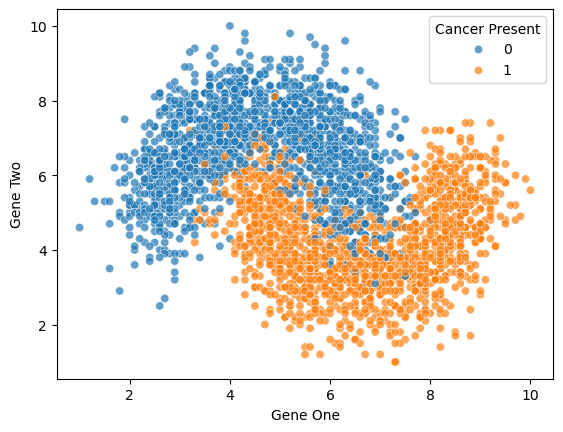

In [49]:
sns.scatterplot(x="Gene One",y="Gene Two",hue="Cancer Present",data=df,alpha=0.7)

In [50]:
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [52]:
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [82]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=22)
knn_model.fit(scaled_X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",22
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [83]:
y_pred = knn_model.predict(scaled_X_test)
accuracy_score(y_test,y_pred)

0.9488888888888889

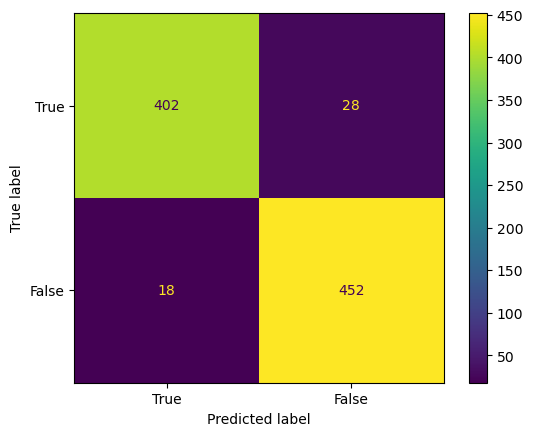

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,
                                        labels=[1,0],
                                        display_labels=["True","False"])

In [57]:
test_error_rates = []
for k in range(1,30):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_X_train,y_train)
    y_pred_test =  knn_model.predict(scaled_X_test)
    test_error = 1 - accuracy_score(y_test,y_pred_test)
    test_error_rates.append(test_error)


Text(0.5, 0, 'K Value')

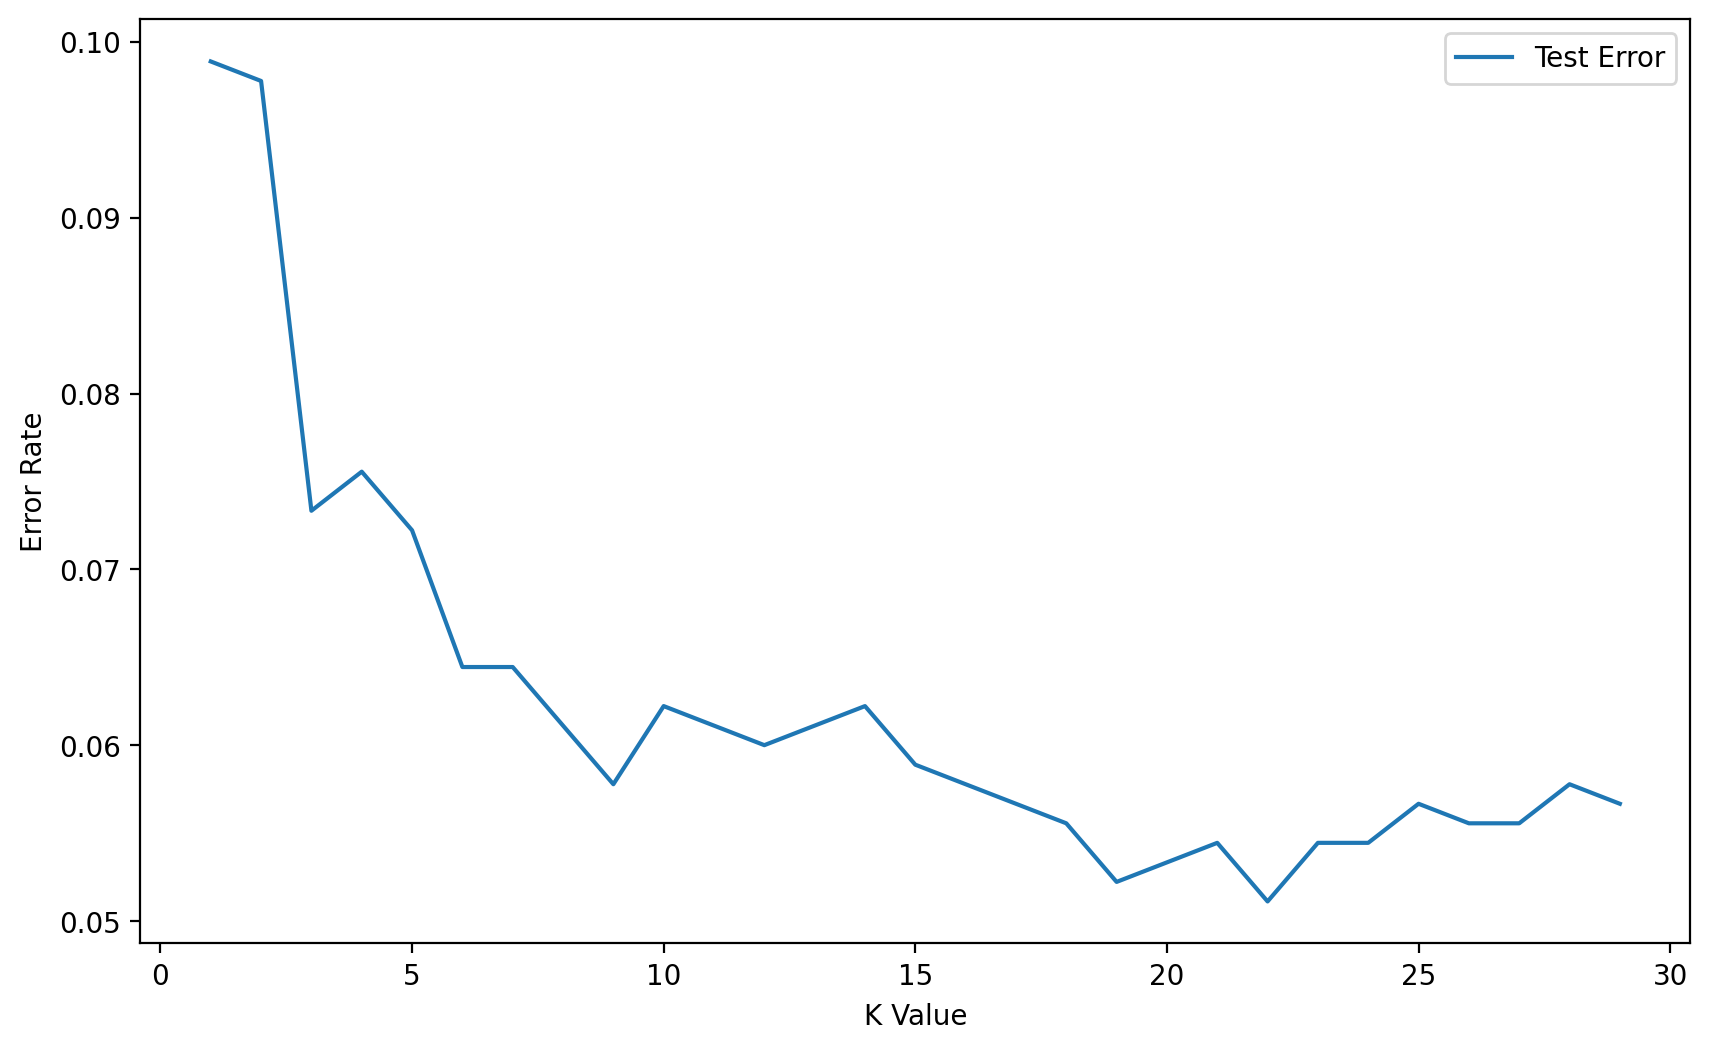

In [58]:
plt.figure(figsize=(10,6),dpi=200)
plt.plot(range(1,30),test_error_rates,label='Test Error')
plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")

## 作業

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
df = pd.read_csv("./gene_expression.csv")
X = df.drop("Cancer Present",axis=1)
y = df["Cancer Present"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
knn = KNeighborsClassifier()
from sklearn.pipeline import Pipeline

oprations = [
    ("scaler",scaler),
    ("knn",knn)
]
pipe = Pipeline(oprations)